<a href="https://colab.research.google.com/github/jayalakshmimuppalla/Assigments/blob/main/Bank_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px


In [9]:
df=pd.read_excel('financial_loan.xlsx')
df.head()



,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [6]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [11]:
## Metadata

In [12]:
print("No of Rows:",df.shape[0])

No of Rows: 38576


In [13]:
print("No of Colunms:",df.shape[1])

No of Colunms: 24


In [ ]:
#### Data Types

In [15]:
df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,datetime64[ns]
last_credit_pull_date,datetime64[ns]
last_payment_date,datetime64[ns]


In [17]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


In [18]:
df.count()

,0
id,38576
address_state,38576
application_type,38576
emp_length,38576
emp_title,37138
grade,38576
home_ownership,38576
issue_date,38576
last_credit_pull_date,38576
last_payment_date,38576


In [21]:
### Total Loan Appilications(ID total Count)
total_loan_application =df['id'].count()
print("Total Loan Applications:" ,total_loan_application)

Total Loan Applications: 38576


In [22]:
### MID Total Loan Applications

latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month=latest_issue_date.month

mtd_date = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_loan_applications=mtd_date['id'].count()
print("Monthly Total Loan Applications:",mtd_loan_applications)

Monthly Total Loan Applications: 4314


In [23]:
### Total Funded Amount

total_funded_amount=df['loan_amount'].sum()
print("Total Funded Amount:",total_funded_amount)

Total Funded Amount: 435757075


In [28]:
### Mid -  Total Funded Amount
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month=latest_issue_date.month
mtd_date = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount=mtd_date['loan_amount'].sum()

print("Mid Total Funded Amount:",mtd_total_funded_amount)

Mid Total Funded Amount: 53981425


In [33]:
### Total Amount Recived

total_amount_received=df['total_payment'].sum()
print("Total Amount Received:",total_amount_received)

Total Amount Received: 473070933


In [36]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month=latest_issue_date.month
mtd_date = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received=mtd_date['total_payment'].sum()

print("total_amount_received:",mtd_total_amount_received)

total_amount_received: 58074380


In [41]:
### Avg Intrest Rate

avg_intrest_rate=df['int_rate'].mean()*100
print("Avg Intrest Rate:",avg_intrest_rate)

Avg Intrest Rate: 12.048831397760265


In [45]:
avg_dti=df['dti'].mean()*100
print("Avg DTI:",avg_dti)

Avg DTI: 13.327433119037742


In [51]:
## Good Loan Metrics

total_loan = df[df['loan_status'].isin(["Fully Paid","Current"])]
total_loan_ap = df['id'].count()

good_loan_applications = total_loan['id'].count()
good_loan_funded_amount = total_loan['loan_amount'].sum()
good_loan_received = total_loan['total_payment'].sum()

good_loan_percentage = (good_loan_applications / total_loan_ap) * 100
print("Good Loan Applications:",good_loan_applications)
print("Good Loan Funded Amount:",good_loan_funded_amount)
print("Good Loan Received:",good_loan_received)
print("Good Loan Percentage:",good_loan_percentage)


Good Loan Applications: 33243
Good Loan Funded Amount: 370224850
Good Loan Received: 435786170
Good Loan Percentage: 86.17534218166736


In [60]:
### Bad Loan

bad_loan = df[df['loan_status'].isin(["Charged Off"])]
total_loan_ap = df['id'].count()

bad_loan_applications = bad_loan['id'].count()
bad_loan_funded_amount = bad_loan['loan_amount'].sum()
bad_loan_received = bad_loan['total_payment'].sum()

bad_loan_percentage = (bad_loan_applications / total_loan_ap) * 100
print("bad Loan Applications:",bad_loan_applications)
print("bad Loan Funded Amount:",bad_loan_funded_amount)
print("bad Loan Received:",bad_loan_received)
print("bad Loan Percentage:",bad_loan_percentage)

bad Loan Applications: 5333
bad Loan Funded Amount: 65532225
bad Loan Received: 37284763
bad Loan Percentage: 13.824657818332643


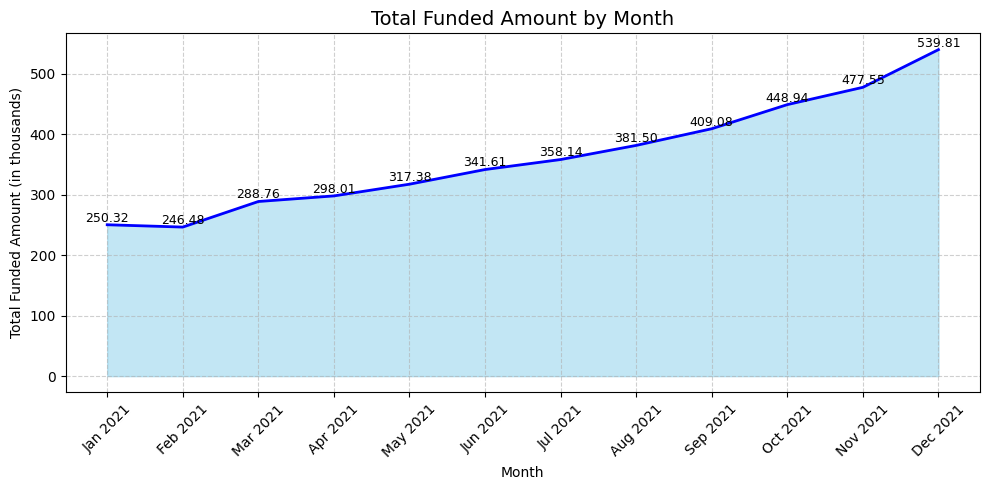

In [69]:
## charts
## Monthly trend by issue date
monthly_funded = df.sort_values('issue_date').assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %Y')).groupby('month_name',sort=False)['loan_amount'].sum().div(1_000_00).reset_index(name='loan_amount')
plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount'],color='skyblue',alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount'],color='blue',linewidth=2)

for i, row in monthly_funded.iterrows():
  plt.text(i, row['loan_amount'] + 0.1, f"{row['loan_amount']:.2f}",
  ha='center', va='bottom',fontsize=9,rotation=0,color='black')

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Funded Amount (in thousands)')
plt.xticks(ticks=range(len(monthly_funded)), labels=monthly_funded['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=.6)
plt.tight_layout()
plt.show()


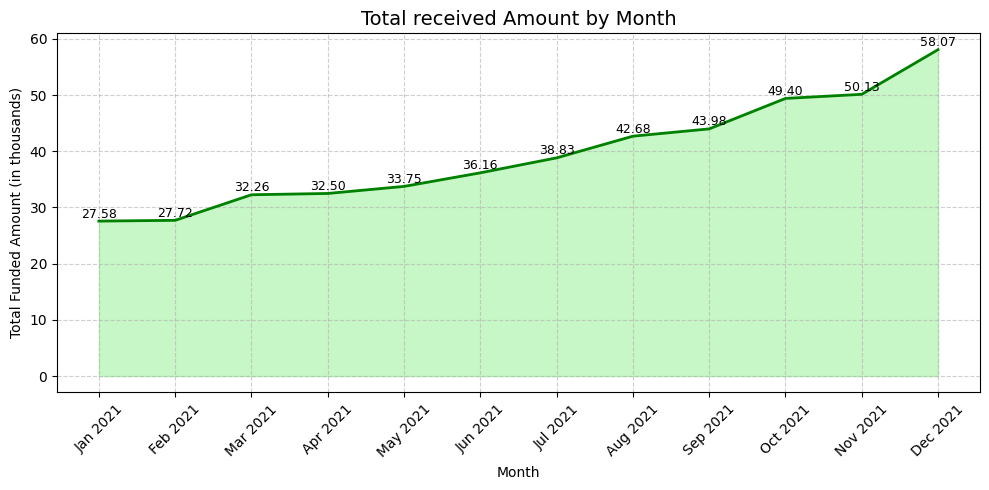

In [10]:
## Monthly trend by issue date for Total Amount Received

monthly_received = df.sort_values('issue_date').assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %Y')).groupby('month_name',sort=False)['total_payment'].sum().div(1000000).reset_index(name='received_amount')
plt.figure(figsize=(10,5))
plt.fill_between(monthly_received['month_name'],monthly_received['received_amount'],color='lightgreen',alpha=0.5)
plt.plot(monthly_received['month_name'],monthly_received['received_amount'],color='green',linewidth=2)

for i, row in monthly_received.iterrows():
  plt.text(i, row['received_amount'] + 0.1, f"{row['received_amount']:.2f}",
  ha='center', va='bottom',fontsize=9,rotation=0,color='black')

plt.title('Total received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Funded Amount (in thousands)')
plt.xticks(ticks=range(len(monthly_received)), labels=monthly_received['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=.6)
plt.tight_layout()
plt.show()